In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Pyfile_ahm_data.csv",sep=",")

,title,Rera registered,property_type,total_units,possession_status,Price,Location,Builder,Min Price,Max Price,Average Price
0,Ansh Aaradhya,Yes,2 BHK Apartment,91,Upcoming Projects,60 - 65 Lac,Khoraj,Ansh Group,60.00,65.00,62.500
1,Patrakar Heights,No,2 BHK Apartment,NaN,Upcoming Projects,NaN,Naranpura,Samyag Group,NaN,NaN,NaN
2,Poonam Pride,Yes,4 BHK Apartment,172,Completed Projects,2.25 Cr.,Shela,B R Developers,225.00,225.00,225.000
3,Shagun Saral 207,Yes,3 BHK Apartment,192,Upcoming Projects,NaN,Zundal,aditya buildcon,NaN,NaN,NaN
4,Express View City,No,Residential Plot,NaN,Upcoming Projects,NaN,Dholera,Kavvan Infrra,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
985,Maruti Celosia Greenscapes 2,No,Residential Plot,186,Completed Projects,NaN,Changodar,Maruti Group,NaN,NaN,NaN
986,Magnanimous Pearl 2,No,Residential Plot,196,Completed Projects,5.40 Lac,Dholera,Magnanimous Infrastructure Pvt. Ltd,5.40,5.40,5.400
987,Magnanimous Pearl,No,Residential Plot,165,Completed Projects,4 - 17.98 Lac,Dholera,Magnanimous Infrastructure Pvt. Ltd,4.00,17.98,10.990
988,Magnanimous Pearl 3,No,Residential Plot,124,Completed Projects,6.30 - 32.29 Lac,Dholera,Magnanimous Infrastructure Pvt. Ltd,6.30,32.29,19.295


In [4]:
# function to segragate distinct property types
def simplify_property_type(ptype):
    ptype = str(ptype).lower()
    
    if "apartment" in ptype or "flat" in ptype:
        return "Apartment"
    elif "plot" in ptype:
        return "Plot"
    elif "land" in ptype:
        return "Land"
    elif "house" in ptype or "villa" in ptype:
        return "House"
    elif "office" in ptype:
        return "Office Space"
    elif "shop" in ptype or "showroom" in ptype:
        return "Commercial Shop/Showroom"
    elif "industrial" in ptype:
        return "Industrial Property"
    elif "hotel" in ptype or "restaurant" in ptype:
        return "Hotel/Restaurant"
    elif "studio" in ptype:
        return "Studio Apartment"
    elif "business" in ptype or "center" in ptype:
        return "Business Center"
    elif "penthouse" in ptype:
        return "Penthouse"
    else:
        return "Other"


In [5]:
df['Distinct_Type'] = df['property_type'].apply(simplify_property_type) # applying the function to create a new column

In [ ]:
# df[(df['Rera registered'] == "No") & (df['possession_status'] == 'Completed Projects')]
# df[(df['Location'] == "Shyamal")]
# df.groupby('Location', as_index=False)['Average Price'].mean().sort_values('Average Price', ascending=False)

,title,Rera registered,property_type,total_units,possession_status,Price,Location,Builder,Min Price,Max Price,Average Price,Distinct_Type
238,Iconic Shyamal,Yes,Office Space,NaN,Ongoing Projects,64.50 Lac,Shyamal,Not known,64.5,64.5,64.5,Office Space
335,Shangrila Arcade,No,Office Space,NaN,Completed Projects,1.71 Cr.,Shyamal,Not known,171.0,171.0,171.0,Office Space
443,Shilp Zaveri,Yes,Business Center,NaN,Upcoming Projects,55 Lac - 10.42 Cr.,Shyamal,Zaveri Realty,55.0,1042.0,548.5,Business Center


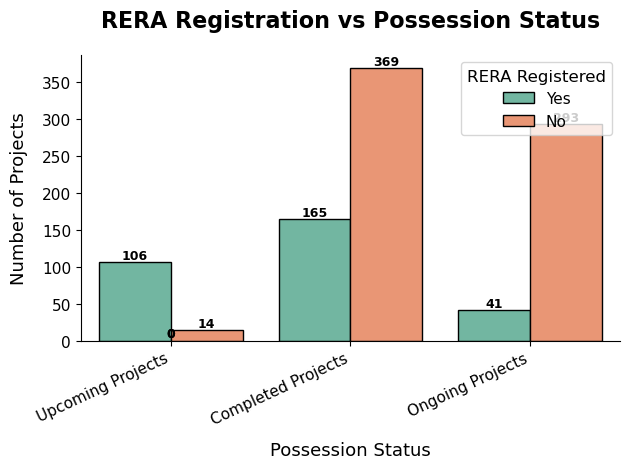

In [7]:
ax = sns.countplot(
    data=df,
    x='possession_status',
    hue='Rera registered',     # Compare RERA status within each possession category
    palette='Set2',
    edgecolor='black'
)

# Title & labels
plt.title("RERA Registration vs Possession Status", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Possession Status", fontsize=13, labelpad=10)
plt.ylabel("Number of Projects", fontsize=13, labelpad=10)
plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Legend
plt.legend(
    title="RERA Registered",
    title_fontsize=12,
    fontsize=11,
    loc='upper right',
    frameon=True
)

# Add count labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 0.5,
        f'{int(height)}',
        ha='center', va='bottom',
        fontsize=9, fontweight='semibold'
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

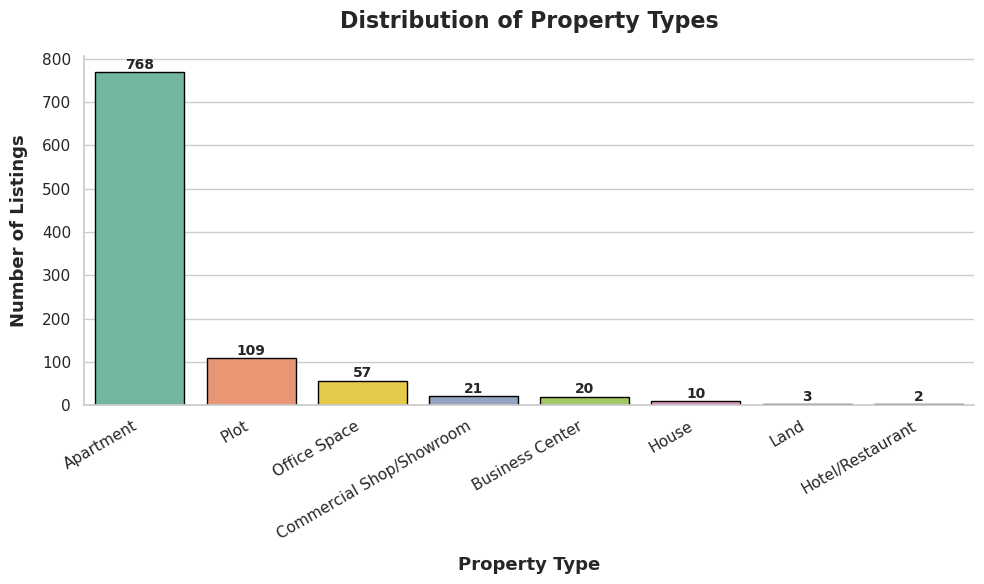

In [8]:
plt.figure(figsize=(10,6))


sns.set_theme(style="whitegrid")
ax = sns.countplot(
    data=df,
    x='Distinct_Type',
    hue='Distinct_Type',           # ← use hue instead of palette
    legend=False,                  # ← disable legend
    palette='Set2',                # still use color palette
    order=df['Distinct_Type'].value_counts().index,
    edgecolor='black'
)

# Beautify labels and title
plt.title("Distribution of Property Types", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Property Type", fontsize=13, labelpad=10,fontweight='bold')
plt.ylabel("Number of Listings", fontsize=13, labelpad=10,fontweight='bold')

# Rotate x-ticks for readability
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Add light borders and remove top/right spines for cleaner look
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()


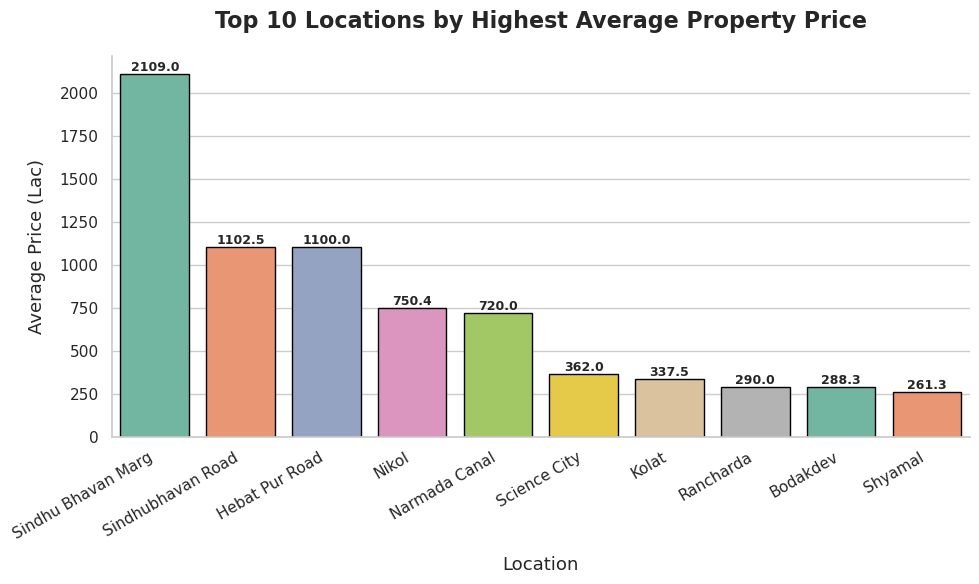

In [16]:
# Prepare data (top 10 locations by mean price)
avg_price_loc = (
    df.groupby('Location', as_index=False)['Average Price']
      .mean()
      .sort_values('Average Price', ascending=False)
      .head(10)
)

# Plot using hue (optional trick to apply palette without warning)
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=avg_price_loc,
    x='Location',
    y='Average Price',
    hue='Location',          # avoids palette-without-hue deprecation
    palette='Set2',
    legend=False,
    edgecolor='black'
)

plt.title("Top 10 Locations by Highest Average Property Price", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Location", fontsize=13, labelpad=10)
plt.ylabel("Average Price (Lac)", fontsize=13, labelpad=10)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='semibold'
    )

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()



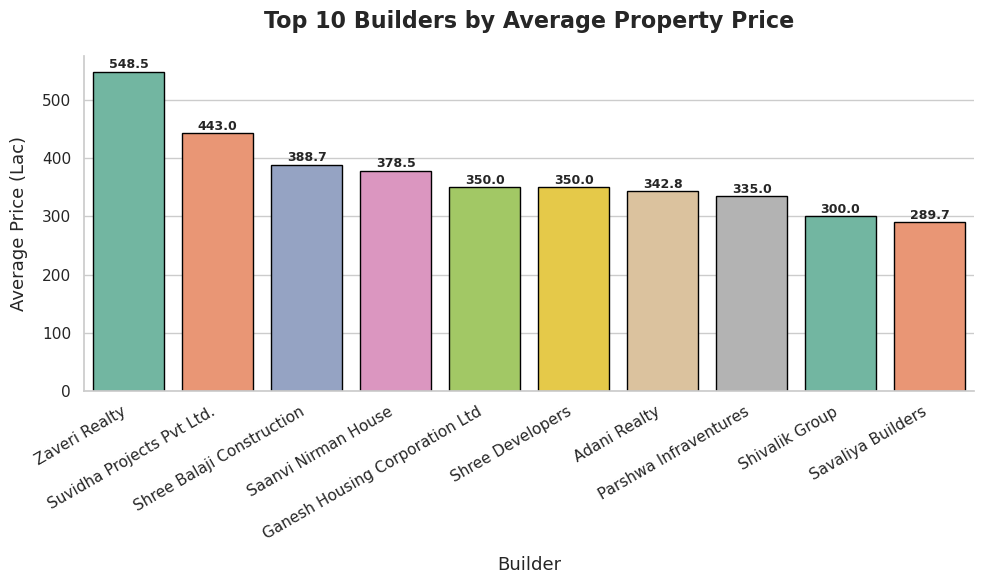

In [10]:
#  Compute top 10 builders by average price
builder_price = (
    df.groupby('Builder', as_index=False)['Average Price']
      .mean()
      .sort_values('Average Price', ascending=False)
      .head(10)
)

# Create the bar plot
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=builder_price,
    x='Builder',
    y='Average Price',
    hue='Builder',          
    palette='Set2',
    legend=False,
    edgecolor='black'
)

# Titles and labels
plt.title("Top 10 Builders by Average Property Price", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Builder", fontsize=13, labelpad=10)
plt.ylabel("Average Price (Lac)", fontsize=13, labelpad=10)

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Add price labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 0.5,
        f'{height:.1f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='semibold'
    )

# Clean up look
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Apartment'),
  Text(1, 0, 'Plot'),
  Text(2, 0, 'Commercial Shop/Showroom'),
  Text(3, 0, 'House'),
  Text(4, 0, 'Business Center'),
  Text(5, 0, 'Office Space'),
  Text(6, 0, 'Land'),
  Text(7, 0, 'Hotel/Restaurant')])

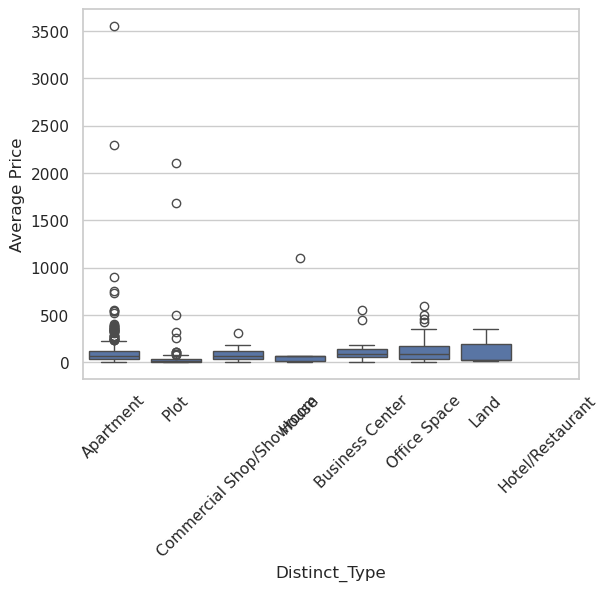

In [11]:
sns.boxplot(data=df,x='Distinct_Type',y="Average Price")
plt.xticks(rotation=45)

<Axes: xlabel='Rera registered', ylabel='Average Price'>

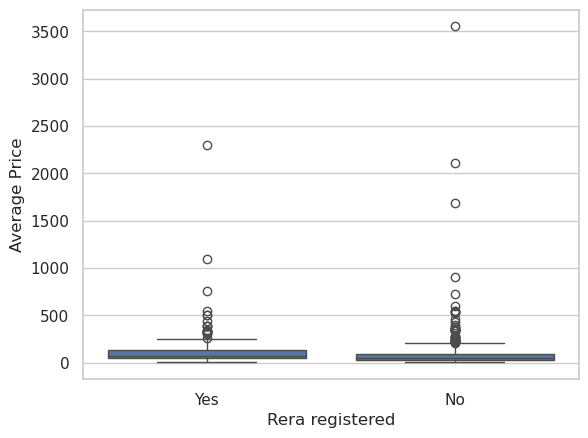

In [12]:
sns.boxplot(data=df, x='Rera registered', y='Average Price')